# BF + BOF + CCS steel NPV simulation

Run the Monte Carlo simulation for the BF + BOF + CCS steel retrofit and visualize its total NPV, LPM, and LCOS (steel LCOX) distributions. The NPV summary also reports the number and share of simulations with non-negative versus negative NPV.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from steel.steel_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_steel_results,
)

from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution


In [2]:
TECHNOLOGY = "bf_bof_ccs"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_steel_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tcs,lifetime_years,capex_eur_per_tcs,fixed_opex_eur_per_tcs,variable_opex_eur_per_tcs,fuel_type,...,bau_variable_opex_eur_per_tcs,bau_fuel_consumption_mwh_th_per_tcs,bau_electricity_consumption_mwh_per_tcs,bau_emissions_tco2_per_tcs,capex_change_eur_per_tcs,fixed_opex_change_eur_per_tcs,variable_opex_change_eur_per_tcs,fuel_consumption_reduction_fraction,electricity_consumption_reduction_fraction,emissions_reduction_fraction
0,0,bf_bof_ccs,retrofit,sampled,1000000.0,20.0,854.180234,48.771010,311.451697,pci_coking_coal_mix,...,307.300117,5.632158,0.115,1.834294,200.087399,6.138003,4.151580,-0.063166,-1.396766,0.675383
1,1,bf_bof_ccs,retrofit,sampled,1000000.0,20.0,844.689243,52.095022,333.577691,pci_coking_coal_mix,...,329.286808,5.572096,0.115,1.800083,202.319132,6.426747,4.290883,-0.101376,-1.382641,0.713693
2,2,bf_bof_ccs,retrofit,sampled,1000000.0,20.0,825.110769,49.841115,294.425936,pci_coking_coal_mix,...,290.184429,5.586004,0.115,1.833429,192.247314,7.726389,4.241508,-0.171361,-4.769664,0.679525
3,3,bf_bof_ccs,retrofit,sampled,1000000.0,20.0,718.988850,48.650684,308.905369,pci_coking_coal_mix,...,304.646539,5.558265,0.115,1.827399,203.807757,7.955478,4.258830,-0.147955,-3.443718,0.681843
4,4,bf_bof_ccs,retrofit,sampled,1000000.0,20.0,705.179978,52.282749,319.655079,pci_coking_coal_mix,...,315.174042,5.587764,0.115,1.792002,200.177938,6.909499,4.481036,-0.035529,-1.693594,0.551090


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcos_eur_per_tcs = results["lcos_eur_per_tcs"]
levelized_profit_margin_eur_per_tcs = results["levelized_profit_margin_eur_per_tcs"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        lcos_eur_per_tcs.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "LCOS EUR/tCS"
        ),
        levelized_profit_margin_eur_per_tcs.describe(
            percentiles=[0.05, 0.5, 0.95]
        ).rename("Levelized profit margin EUR/tCS"),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,LCOS EUR/tCS,Levelized profit margin EUR/tCS
count,100000.000000,100000.000000,100000.000000
mean,402.386810,709.016015,40.983985
std,356.481525,36.308431,36.308431
min,-877.656535,592.901292,-89.391257
5%,-209.697771,651.683344,-21.358181
50%,418.563681,707.368365,42.631635
95%,965.287420,771.358181,98.316656
max,1542.418273,839.391257,157.098708


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),86099,0.86099
1,Negative (NPV < 0),13901,0.13901


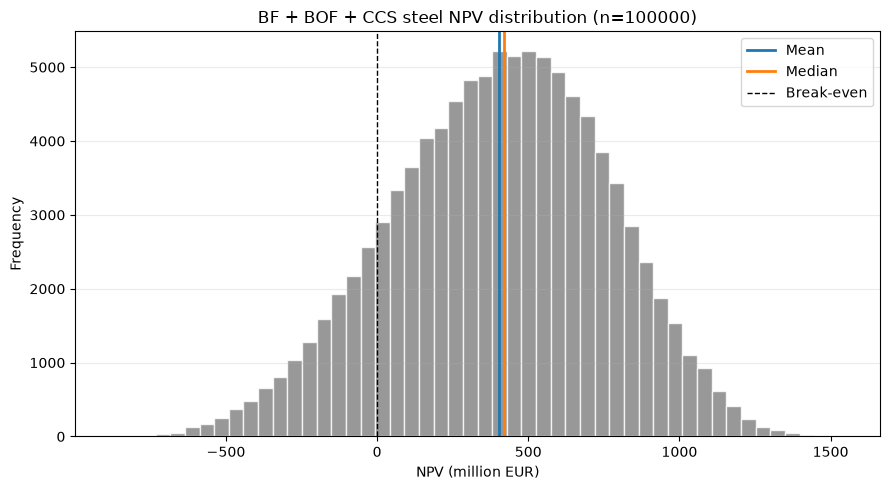

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"BF + BOF + CCS steel NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()


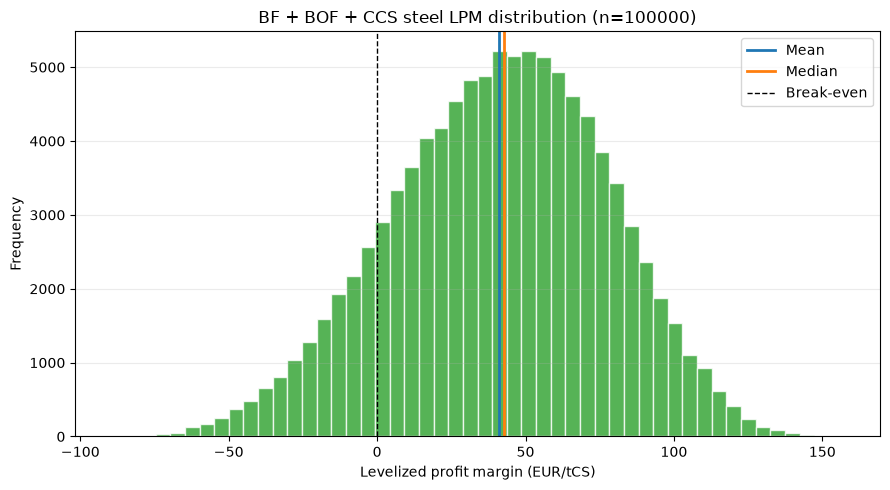

In [5]:
plot_financial_metric_distribution(
    levelized_profit_margin_eur_per_tcs,
    title=f"BF + BOF + CCS steel LPM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized profit margin (EUR/tCS)",
    color="tab:green",
    show_break_even=True,
)
plt.show()


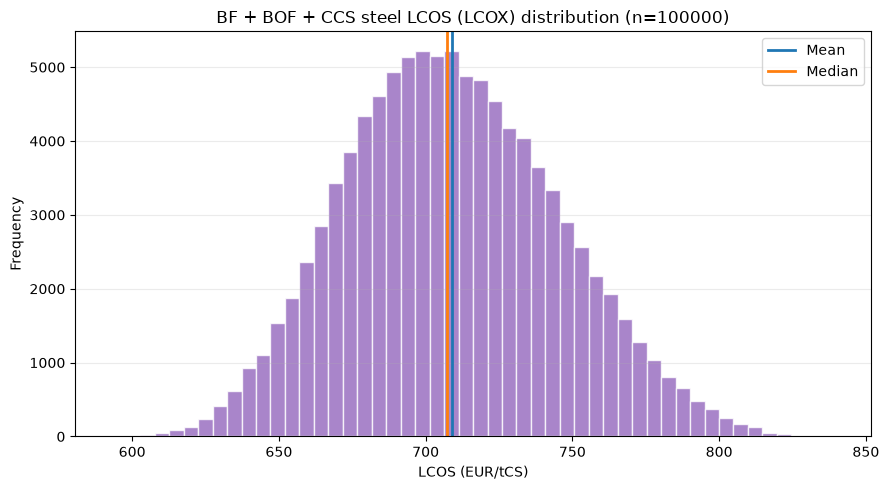

In [6]:
plot_financial_metric_distribution(
    lcos_eur_per_tcs,
    title=f"BF + BOF + CCS steel LCOS (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOS (EUR/tCS)",
    color="tab:purple",
)
plt.show()


In [7]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_transport_and_storage_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur"
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur                       750.000000
annual_fixed_opex_eur                     50.098159
annual_variable_opex_eur                 317.794312
annual_fuel_cost_eur                     142.631428
annual_electricity_cost_eur               51.686364
annual_transport_and_storage_cost_eur     15.857543
annual_emissions_cost_eur                 49.485202
annual_net_cash_flow_eur                 122.446990
Name: Mean annual value, million EUR, dtype: float64

In [8]:
retrofit_columns = [
    "capex_change_eur_per_tcs",
    "fixed_opex_change_eur_per_tcs",
    "variable_opex_change_eur_per_tcs",
    "fuel_consumption_reduction_fraction",
    "electricity_consumption_reduction_fraction",
    "emissions_reduction_fraction",
    "bau_capex_eur_per_tcs",
    "bau_fixed_opex_eur_per_tcs",
    "bau_variable_opex_eur_per_tcs",
    "bau_fuel_consumption_mwh_th_per_tcs",
    "bau_electricity_consumption_mwh_per_tcs",
    "bau_emissions_tco2_per_tcs",
    "transport_and_storage_share_of_capture_cost",
    "capture_cost_excluding_transport_and_storage_eur_per_tcs",
    "transport_and_storage_cost_eur_per_tcs",
]

available_retrofit_columns = [
    column for column in retrofit_columns if column in results
]
retrofit_summary = results[available_retrofit_columns].describe(
    percentiles=[0.05, 0.5, 0.95]
)
retrofit_summary


,capex_change_eur_per_tcs,fixed_opex_change_eur_per_tcs,variable_opex_change_eur_per_tcs,fuel_consumption_reduction_fraction,electricity_consumption_reduction_fraction,emissions_reduction_fraction,bau_capex_eur_per_tcs,bau_fixed_opex_eur_per_tcs,bau_variable_opex_eur_per_tcs,bau_fuel_consumption_mwh_th_per_tcs,bau_electricity_consumption_mwh_per_tcs,bau_emissions_tco2_per_tcs,transport_and_storage_share_of_capture_cost,capture_cost_excluding_transport_and_storage_eur_per_tcs,transport_and_storage_cost_eur_per_tcs
count,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,1.000000e+05,100000.000000,100000.000000
mean,204.107466,7.096315,4.499622,-1.100017e-01,-2.856264,0.660121,595.708321,43.001845,313.294691,5.586807,1.150000e-01,1.819976,1.870000e-01,84.799697,15.857543
std,15.581749,0.577378,0.230983,6.361434e-02,1.644210,0.049549,70.246671,1.635652,15.308932,0.081954,1.387786e-17,0.020386,2.775571e-17,25.368977,4.743999
min,177.000251,6.100008,4.100003,-2.199926e-01,-5.699980,0.520912,425.825143,39.015064,270.420110,5.400847,1.150000e-01,1.770230,1.870000e-01,30.011474,5.612146
5%,179.732786,6.200276,4.140158,-2.091048e-01,-5.414263,0.566835,479.253112,40.266742,284.482819,5.456891,1.150000e-01,1.785864,1.870000e-01,46.720396,8.736714
50%,204.209473,7.096157,4.498697,-1.101414e-01,-2.860287,0.668722,594.607748,42.996219,315.914181,5.580827,1.150000e-01,1.819954,1.870000e-01,83.172313,15.553223
95%,228.330212,8.002103,4.859886,-1.096003e-02,-0.292642,0.724773,714.299300,45.742363,333.354491,5.730335,1.150000e-01,1.854139,1.870000e-01,129.232633,24.166502
max,230.999282,8.099970,4.899999,-5.898744e-08,-0.000019,0.730000,768.957094,46.996992,334.999646,5.799559,1.150000e-01,1.869842,1.870000e-01,169.567519,31.709126
